In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
import numpy as np
import matplotlib.pyplot as plt
import os
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from sklearn.metrics import roc_auc_score
from torchsummary import summary
from tqdm import tqdm
import sys

sys.path.insert(0,'..')

In [20]:
data_dir = os.path.join('dataset','train')

View Individual Images

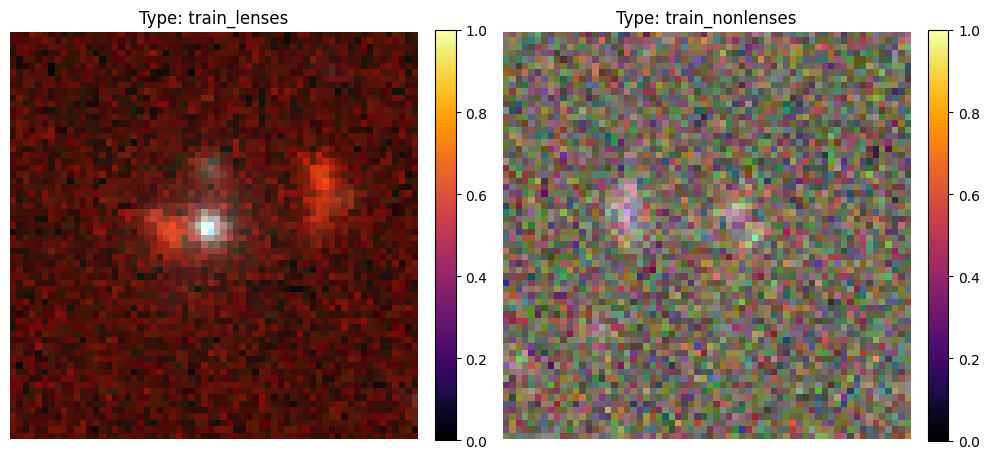

In [21]:

classes = ['train_lenses','train_nonlenses']
fig, axes = plt.subplots(1,2, figsize=(10,5))

for i,cl in enumerate(classes):
    class_path = os.path.join(data_dir,cl)
    file_name = [f for f in os.listdir(class_path) if f.endswith('.npy')][0]
    img_array = np.load(os.path.join(class_path,file_name))
    
    # Squeeze and transpose to (H, W, C) if channels-first
    img_plot = img_array.squeeze()
    if img_plot.ndim == 3 and img_plot.shape[0] in (1, 3, 4):
        img_plot = np.transpose(img_plot, (1, 2, 0))
    
    im=axes[i].imshow(img_plot,cmap='inferno')
    axes[i].set_title(f"Type: {cl}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    
plt.tight_layout()
plt.show()


Transforms

In [22]:
transform_norm = transforms.Compose([
    transforms.RandomRotation(180),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

Custom Dataset Class for preparing data

In [23]:
class LensingNpyDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir=root_dir
        self.transform=transform
        self.data=[]
        self.classes=sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        for idx, cl in enumerate(self.classes):
            class_path =os.path.join(root_dir, cl)
            if not os.path.isdir(class_path):
                continue
            for f in os.listdir(class_path):
                if f.endswith('.npy'):
                    self.data.append((os.path.join(class_path,f), idx))
                    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = np.load(img_path).astype(np.float32)
        
        # Ensure (C, H, W) format
        if image.ndim == 2:
            image = image[np.newaxis, ...]       # (H, W) → (1, H, W)
        elif image.ndim == 3 and image.shape[-1] in (1, 3, 4):
            image = np.transpose(image, (2, 0, 1))  # (H, W, C) → (C, H, W)
        
        image = torch.from_numpy(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label


In [24]:
dataset=LensingNpyDataset(root_dir=data_dir, transform=transform_norm)

train_size=int(0.9*len(dataset))
val_size=len(dataset)-train_size
train_data, val_data=random_split(dataset,[train_size, val_size])

Checking Class balance

  0%|          | 0/27364 [00:00<?, ?it/s]

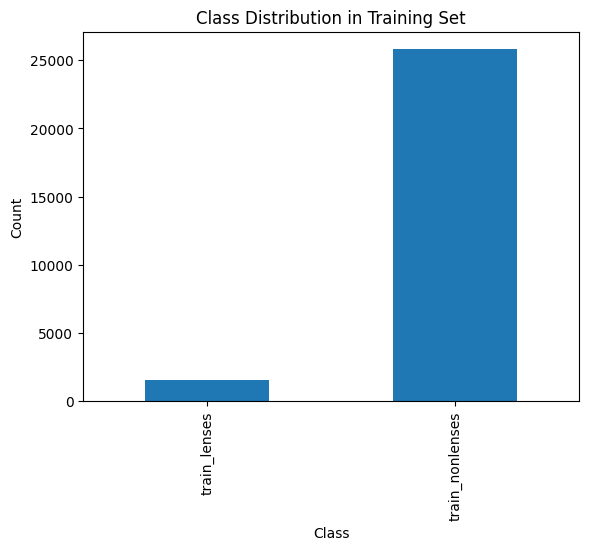

  0%|          | 0/3041 [00:00<?, ?it/s]

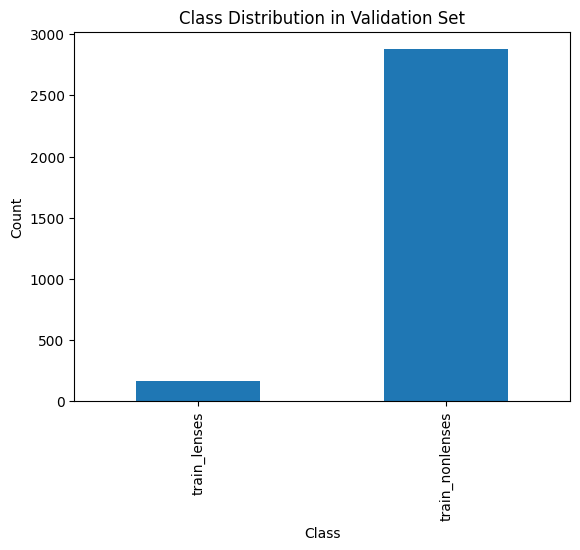

In [27]:
sys.path.insert(0,'..')
from training import class_counts

class_counts(train_data).plot(kind='bar', title='Class Distribution in Training Set', xlabel='Class', ylabel='Count')
plt.show()

class_counts(val_data).plot(kind='bar', title='Class Distribution in Validation Set', xlabel='Class', ylabel='Count')
plt.show()

There is a Massive Class Imbalance. Using WeightedRandomSampler to balance classes.

In [25]:
# Build per-sample weights from the underlying dataset labels
train_labels = [dataset.data[i][1] for i in train_data.indices]
class_counts_tensor = torch.bincount(torch.tensor(train_labels))
class_weights = 1.0 / class_counts_tensor.float()
sample_weights = class_weights[torch.tensor(train_labels)]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
print(f"Class counts: {class_counts_tensor.tolist()}")
print(f"Class weights: {class_weights.tolist()}")
print(f"Sampler length: {len(sampler)}")


Class counts: [1562, 25802]
Class weights: [0.0006402048747986555, 3.875668699038215e-05]
Sampler length: 27364


In [26]:
train_loader=DataLoader(train_data, batch_size=32, sampler=sampler, num_workers=4, pin_memory=True)
val_loader=DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


Checking shapes of data and labels

In [27]:
images, labels=next(iter(train_loader))
print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")

Batch of images shape: torch.Size([32, 3, 64, 64])
Batch of labels shape: torch.Size([32])


Using ResNet50 architecture. I am changing the first and last layer of the ResNet50 network for this task.

## Physics-Informed Neural Network (PINN) for Gravitational Lensing Classification

This notebook implements a **Physics-Informed Neural Network (PINN)** that embeds the
**gravitational lensing equation** directly into the forward pass.

### The Gravitational Lensing Equation
The reduced deflection angle for a Singular Isothermal Sphere (SIS) lens:

```
β = θ - α(θ),   α_SIS(θ) = θ_E · θ / |θ|
```

- **β** = source-plane position  
- **θ** = observed image position  
- **θ_E** = Einstein radius (learnable parameter)  
- **α** = SIS deflection + small data-driven correction (learned)

The `GravitationalLensingLayer` warps the input image from the *image plane*
to the *source plane* before the CNN backbone sees it, giving the model
a physically motivated inductive bias that distinguishes no-substructure,
subhalo, and vortex lensing patterns more cleanly than a pure CNN.


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Physics-Informed Lensing Layer
# ─────────────────────────────────────────────────────────────────────────────

class GravitationalLensingLayer(nn.Module):
    """
    Differentiable gravitational lensing layer.

    Implements the reduced lensing equation:
        beta = theta - alpha(theta)
    where alpha is composed of:
      - Analytical SIS component: alpha_SIS = theta_E * theta / |theta|
      - Learned residual correction: alpha_NN  (small CNN branch)

    The image is warped from the image plane to the source plane
    using differentiable bilinear grid sampling, so gradients flow
    back through the physics into the backbone.

    Args:
        in_channels (int): Number of input image channels (3 for RGB).
        img_size (int): Spatial size of the square input image.
        hidden_dim (int): Number of channels in the deflection-field predictor.
        einstein_radius_init (float): Initial θ_E in normalised [-1, 1] units.
    """

    def __init__(self, in_channels: int = 3, img_size: int = 64,
                 hidden_dim: int = 16, einstein_radius_init: float = 0.3):
        super().__init__()
        self.img_size = img_size

        # Learnable Einstein radius (stored in log-space to keep it positive)
        self.log_einstein_radius = nn.Parameter(
            torch.tensor(float(torch.tensor(einstein_radius_init).log()))
        )

        # Lightweight CNN to predict per-pixel deflection corrections (2-channel)
        self.deflection_net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, 2, kernel_size=1),   # alpha_x, alpha_y
            nn.Tanh()                                   # bounded output
        )

        # Normalised θ grid pre-computed once; shape: 1 × H × W × 2
        self.register_buffer('theta_grid', self._make_theta_grid(img_size))

    @staticmethod
    def _make_theta_grid(size: int) -> torch.Tensor:
        """Normalised coordinate grid in [-1, 1]² matching grid_sample convention."""
        lin = torch.linspace(-1.0, 1.0, size)
        gy, gx = torch.meshgrid(lin, lin, indexing='ij')   # H × W
        grid = torch.stack([gx, gy], dim=-1)               # H × W × 2
        return grid.unsqueeze(0)                            # 1 × H × W × 2

    def _sis_deflection(self, theta: torch.Tensor) -> torch.Tensor:
        """
        Analytical SIS deflection field.

        alpha_SIS(theta) = theta_E * theta / |theta|

        Args:
            theta: B × H × W × 2  (normalised image-plane positions)
        Returns:
            B × H × W × 2  deflection vectors
        """
        einstein_r = self.log_einstein_radius.exp()
        norm = theta.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        return einstein_r * theta / norm

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Warp the input image to the source plane.

        Args:
            x: B × C × H × W  (image-plane pixels)
        Returns:
            B × C × H × W  (source-plane pixels, same shape)
        """
        B = x.size(0)

        # 1. Expand θ grid to batch
        theta = self.theta_grid.expand(B, -1, -1, -1)      # B × H × W × 2

        # 2. Analytical SIS deflection
        alpha_sis = self._sis_deflection(theta)              # B × H × W × 2

        # 3. Data-driven deflection correction (scaled to ≤10% of SIS)
        alpha_nn = self.deflection_net(x)                    # B × 2 × H × W
        alpha_nn = alpha_nn.permute(0, 2, 3, 1) * 0.1       # B × H × W × 2

        # 4. Total deflection → source position: beta = theta - alpha
        beta = theta - (alpha_sis + alpha_nn)                # B × H × W × 2

        # 5. Differentiable bilinear warping (beta stays in [-1,1] )
        warped = F.grid_sample(
            x, beta,
            mode='bilinear',
            padding_mode='border',
            align_corners=True
        )
        return warped


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# PINN Model: Lensing Layer + ResNet-50 Backbone
# ─────────────────────────────────────────────────────────────────────────────

class PINNLensingClassifier(nn.Module):
    """
    Physics-Informed Neural Network for gravitational lensing classification.

    Forward pass:
        x (B×1×H×W)
          ──► GravitationalLensingLayer  (beta = theta - alpha)
          ──► ResNet-50 backbone         (frozen layer1-2, fine-tuned layer3-4)
          ──► Classification head        (2048 → 256 → num_classes)

    Args:
        num_classes (int): Number of output classes (3: no / subhalo / vortex).
        img_size (int): Input image size (pixels).
        dropout (float): Dropout probability in the classification head.
    """

    def __init__(self, num_classes: int = 2, img_size: int = 64,
                 dropout: float = 0.5):
        super().__init__()

        # ── 1. Physics layer ──────────────────────────────────
        self.lensing_layer = GravitationalLensingLayer(
            in_channels=3,
            img_size=img_size,
            hidden_dim=16,
            einstein_radius_init=0.3
        )

        # ── 2. ResNet-50 backbone ─────────────────────────────
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Single-channel first conv (grayscale lensing images)
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2,
                                   padding=3, bias=False)

        # Freeze early feature extractors
        for param in backbone.layer1.parameters():
            param.requires_grad = False
        for param in backbone.layer2.parameters():
            param.requires_grad = False

        # Fine-tune deeper layers
        for param in backbone.layer3.parameters():
            param.requires_grad = True
        for param in backbone.layer4.parameters():
            param.requires_grad = True

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()   # remove original head
        self.backbone = backbone

        # ── 3. Classification head ────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.lensing_layer(x)        # image-plane → source-plane
        features = self.backbone(x)       # 2048-d feature vector
        return self.classifier(features)  # class logits

    def get_einstein_radius(self) -> float:
        """Return the currently learned Einstein radius (normalised units)."""
        return self.lensing_layer.log_einstein_radius.exp().item()


In [30]:
model = PINNLensingClassifier(num_classes=2, img_size=64, dropout=0.5)
print(model)
print(f"\nInitial Einstein radius θ_E: {model.get_einstein_radius():.4f}  (normalised [-1,1] units)")


PINNLensingClassifier(
  (lensing_layer): GravitationalLensingLayer(
    (deflection_net): Sequential(
      (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(16, 2, kernel_size=(1, 1), stride=(1, 1))
      (5): Tanh()
    )
  )
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3

In [31]:
# Differential learning rates across the network:
#   Lensing layer  → moderate (physics params need to move)
#   Early backbone → very low  (frozen layers stay near pretrained weights)
#   Later backbone → higher    (fine-tuning)
#   Head           → highest   (trained from scratch)

params_to_update = [
    {'params': model.lensing_layer.parameters(),           'lr': 1e-4},
    {'params': model.backbone.conv1.parameters(),          'lr': 5e-5},
    {'params': model.backbone.layer1.parameters(),         'lr': 5e-6},
    {'params': model.backbone.layer2.parameters(),         'lr': 5e-6},
    {'params': model.backbone.layer3.parameters(),         'lr': 5e-5},
    {'params': model.backbone.layer4.parameters(),         'lr': 5e-5},
    {'params': model.classifier.parameters(),              'lr': 5e-4},
]

loss_fn  = nn.CrossEntropyLoss()
optimizer = optim.Adam(params_to_update, weight_decay=1e-4)

print("loss function:", loss_fn)
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


loss function: CrossEntropyLoss()
Total trainable parameters: 22,601,269


In [32]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")


Using cuda device.


In [33]:
model.to(device)
summary(model, input_size=(3, 64, 64), batch_size=32)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 16, 64, 64]           1,216
              ReLU-2           [32, 16, 64, 64]               0
            Conv2d-3           [32, 16, 64, 64]           2,320
              ReLU-4           [32, 16, 64, 64]               0
            Conv2d-5            [32, 2, 64, 64]              34
              Tanh-6            [32, 2, 64, 64]               0
GravitationalLensingLayer-7            [32, 3, 64, 64]               0
            Conv2d-8           [32, 64, 32, 32]           9,408
       BatchNorm2d-9           [32, 64, 32, 32]             128
             ReLU-10           [32, 64, 32, 32]               0
        MaxPool2d-11           [32, 64, 16, 16]               0
           Conv2d-12           [32, 64, 16, 16]           4,096
      BatchNorm2d-13           [32, 64, 16, 16]             128
             ReLU-14           [

In [34]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

print("\nTrainable layers:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.numel():,}")


Total parameters:     24,036,661
Trainable parameters: 22,601,269
Frozen parameters:    1,435,392

Trainable layers:
  lensing_layer.log_einstein_radius: 1
  lensing_layer.deflection_net.0.weight: 1,200
  lensing_layer.deflection_net.0.bias: 16
  lensing_layer.deflection_net.2.weight: 2,304
  lensing_layer.deflection_net.2.bias: 16
  lensing_layer.deflection_net.4.weight: 32
  lensing_layer.deflection_net.4.bias: 2
  backbone.conv1.weight: 9,408
  backbone.bn1.weight: 64
  backbone.bn1.bias: 64
  backbone.layer3.0.conv1.weight: 131,072
  backbone.layer3.0.bn1.weight: 256
  backbone.layer3.0.bn1.bias: 256
  backbone.layer3.0.conv2.weight: 589,824
  backbone.layer3.0.bn2.weight: 256
  backbone.layer3.0.bn2.bias: 256
  backbone.layer3.0.conv3.weight: 262,144
  backbone.layer3.0.bn3.weight: 1,024
  backbone.layer3.0.bn3.bias: 1,024
  backbone.layer3.0.downsample.0.weight: 524,288
  backbone.layer3.0.downsample.1.weight: 1,024
  backbone.layer3.0.downsample.1.bias: 1,024
  backbone.layer3.1

In [35]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

/home/rwitobaansheikh/ai_projects/.venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [36]:
from training import train

train_losses, val_losses, train_accuracies, val_accuracies, train_aucs, val_aucs = train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs=150,
    device=device,
    scheduler=scheduler,
    checkpoint_path="model/best_model.pth",
    early_stopping=True
)

print(f"\nLearned Einstein radius θ_E after training: {model.get_einstein_radius():.4f}")


Model evaluation before start of training...


Scoring:   0%|          | 0/856 [00:00<?, ?it/s]

Scoring:   0%|          | 0/96 [00:00<?, ?it/s]



Starting epoch 1/150


Training:   0%|          | 0/856 [00:00<?, ?it/s]

...

Epoch: 22
Training loss: 0.1166
Training accuracy: 96.1190%
Training AUC: 0.9925
Validation loss: 0.1154
Validation accuracy: 95.9882%
Validation AUC: 0.9802


Starting epoch 23/150


Training:   0%|          | 0/856 [00:00<?, ?it/s]

Scoring:   0%|          | 0/856 [00:00<?, ?it/s]

Scoring:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch: 23
Training loss: 0.1010
Training accuracy: 96.7622%
Training AUC: 0.9935
Validation loss: 0.1420
Validation accuracy: 95.8566%
Validation AUC: 0.9862
Early stopping triggered after 23 epochs

Learned Einstein radius θ_E after training: 0.2871


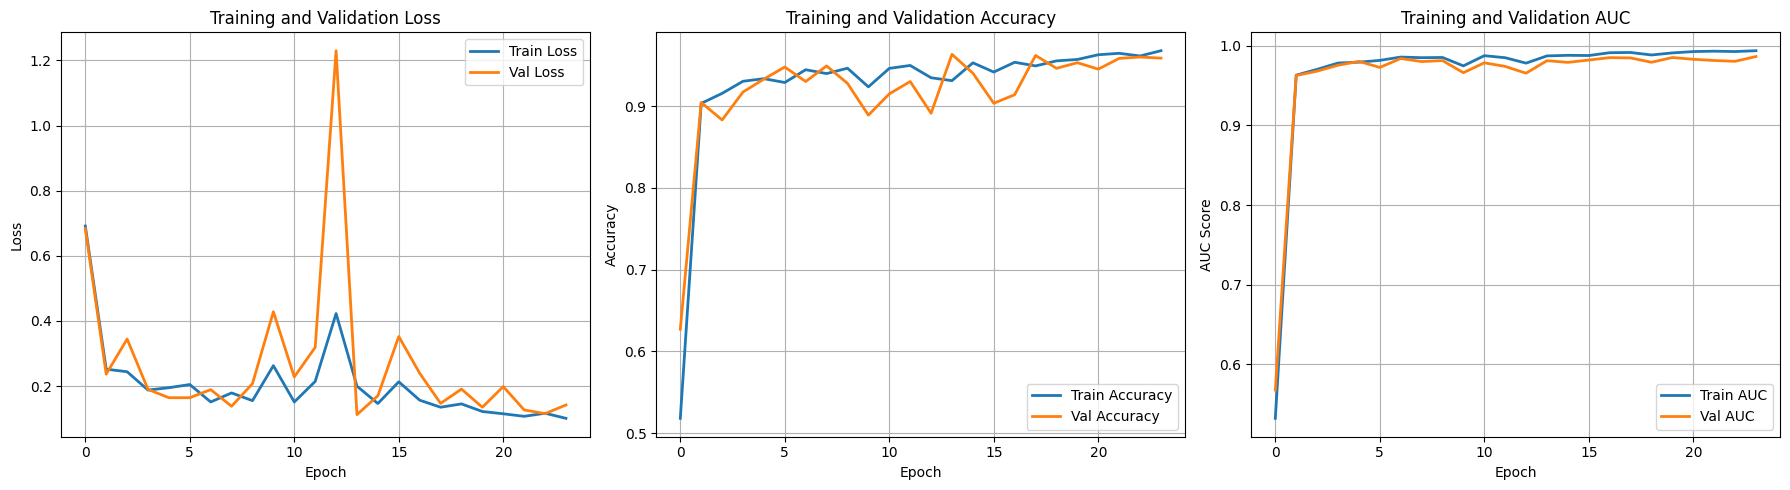

Final Training Accuracy: 0.9676
Final Validation Accuracy: 0.9586
Final Training AUC: 0.9935
Final Validation AUC: 0.9862


In [37]:
# Plot training results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accuracies, label='Train Accuracy', linewidth=2)
axes[1].plot(val_accuracies, label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

# AUC plot
axes[2].plot(train_aucs, label='Train AUC', linewidth=2)
axes[2].plot(val_aucs, label='Val AUC', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC Score')
axes[2].set_title('Training and Validation AUC')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Final Training AUC: {train_aucs[-1]:.4f}")
print(f"Final Validation AUC: {val_aucs[-1]:.4f}")


In [39]:
CHECKPOINT_PATH = "model/best_model.pth"

model = PINNLensingClassifier(num_classes=len(classes), img_size=64, dropout=0.5)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Device: {device}")
print(f"Learned Einstein radius θ_E: {model.get_einstein_radius():.4f}")
print("Checkpoint loaded successfully.")

Device: cuda
Learned Einstein radius θ_E: 0.2920
Checkpoint loaded successfully.


In [40]:
import json as _json

save_dir = "Results"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "pinn_lensing_final.pth")
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

# This handles both raw datasets and Subset objects
try:
    mapping = train_data.dataset.class_to_idx
except AttributeError:
    mapping = train_data.dataset.dataset.class_to_idx

with open(os.path.join(save_dir, "class_mapping.json"), "w") as f:
    _json.dump(mapping, f)


history = {
    'train_losses':      train_losses,
    'val_losses':        val_losses,
    'train_accuracies':  train_accuracies,
    'val_accuracies':    val_accuracies,
    'train_aucs':        [float(a) for a in train_aucs],
    'val_aucs':          [float(a) for a in val_aucs],
    'learned_einstein_radius': model.get_einstein_radius(),
}
with open(os.path.join(save_dir, "training_history.json"), 'w') as hf:
    _json.dump(history, hf, indent=2)
print("History saved.")

Model saved to Results/pinn_lensing_final.pth
History saved.


In [46]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_final_roc(model, dataloader, device, classes, title_suffix=""):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    n_classes = len(classes)
    plt.figure(figsize=(8, 6))

    for i in range(n_classes):
        # For each class, treat it as positive vs all others
        binary_labels = (all_labels == i).astype(int)
        fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {title_suffix}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

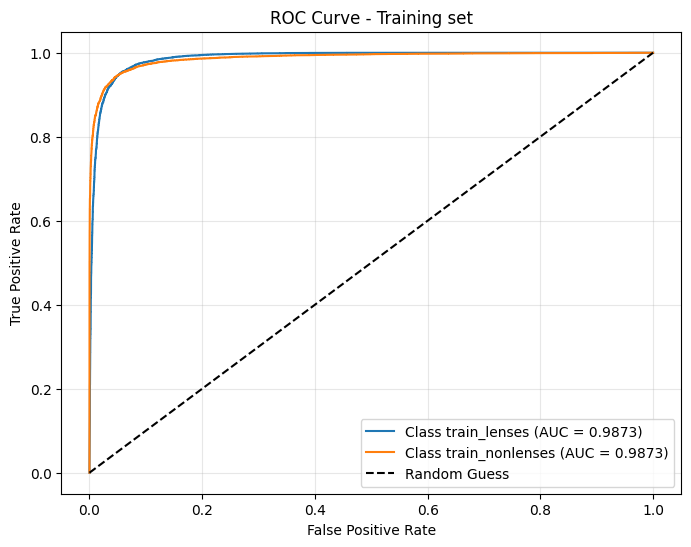

In [47]:
plot_final_roc(model, train_loader, device, ['train_lenses', 'train_nonlenses'], "Training set")

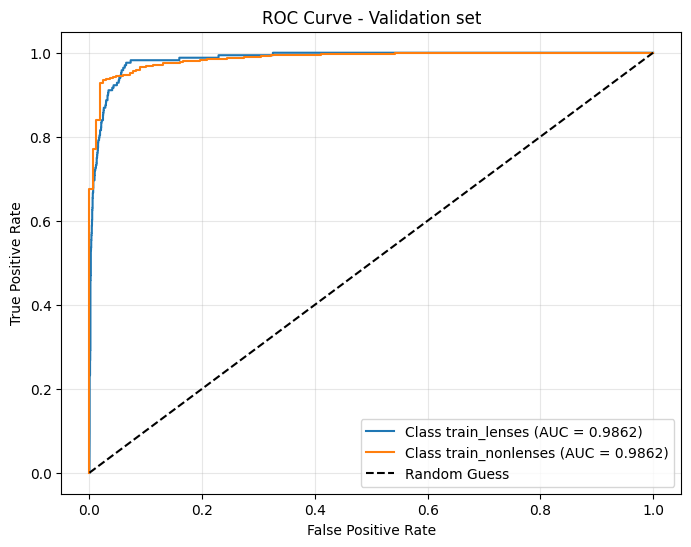

In [48]:
plot_final_roc(model, val_loader, device, ['train_lenses', 'train_nonlenses'], "Validation set")

Evaluating trained Model on Test Set

In [49]:
# Transform for evaluation (no augmentation, just normalization)
transform_eval=transforms.Compose([
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

In [50]:
test_dir= os.path.join('dataset','test')
test_dataset=LensingNpyDataset(root_dir=test_dir, transform=transform_eval)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [51]:
from training import predict
predict?

Signature: predict(model, data_loader, device='cpu')
Docstring: <no docstring>
File:      ~/ai_projects/gsoc_deeplense/training.py
Type:      function

In [52]:
probabilities=predict(model, test_loader, device)
predictions=torch.argmax(probabilities,dim=1)

Predicting:   0%|          | 0/615 [00:00<?, ?it/s]

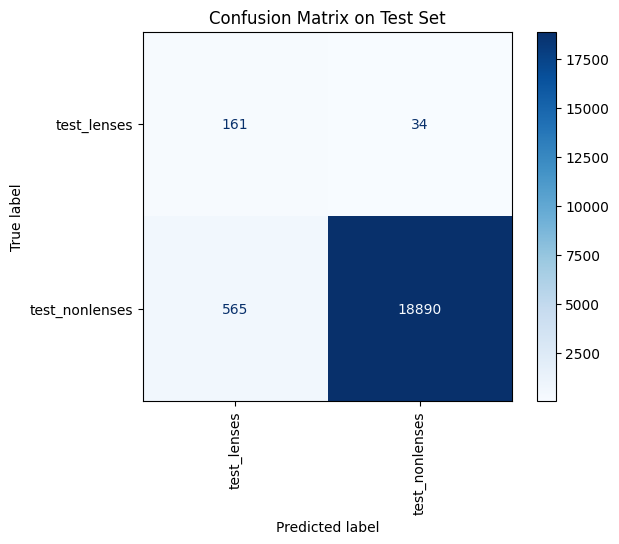

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

targets=[]

for _, labels in test_loader:
    targets.extend(labels.cpu().numpy())
    
cm=confusion_matrix(targets, predictions.cpu().numpy())
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['test_lenses', 'test_nonlenses'])
disp.plot(cmap='Blues', xticks_rotation="vertical")
plt.title("Confusion Matrix on Test Set")
plt.show()

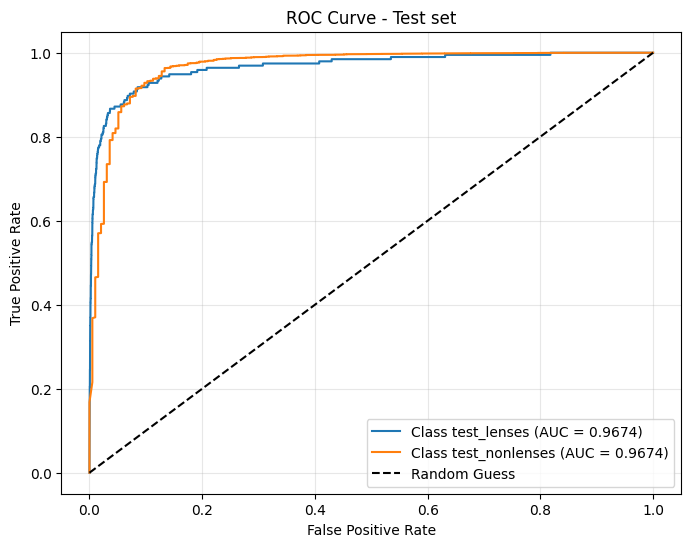

In [54]:
plot_final_roc(model, test_loader, device, ['test_lenses', 'test_nonlenses'], "Test set")